# Adversarial Shilling Attacks on Recommender Systems


In [ ]:
import pandas as pd
import numpy as np
!pip install git+https://github.com/NicolasHug/Surprise.git@fixnp2
import matplotlib.pyplot as plt
from surprise import Dataset, Reader
from collections import defaultdict
from surprise import KNNBasic, SVD
from abc import ABC, abstractmethod
import os
import pickle

from google.colab import drive
drive.mount('/content/drive')

SAVE_DIR = '/content/drive/MyDrive/csci5123hw/shilling_attacks'
os.makedirs(SAVE_DIR, exist_ok=True)
print("Save directory ready:", SAVE_DIR)

  Cloning https://github.com/NicolasHug/Surprise.git (to revision fixnp2) to /tmp/pip-req-build-b0eqo1cp
  Running command git clone --filter=blob:none --quiet https://github.com/NicolasHug/Surprise.git /tmp/pip-req-build-b0eqo1cp
  Running command git checkout -b fixnp2 --track origin/fixnp2
  Switched to a new branch 'fixnp2'
  Branch 'fixnp2' set up to track remote branch 'fixnp2' from 'origin'.
  Resolved https://github.com/NicolasHug/Surprise.git to commit 935a0ea7609ee10897c5d9c6de9ed18df5fdcd93
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for scikit-surprise: filename=scikit_surprise-1.1.4-cp312-cp312-linux_x86_64.whl size=2556281 sha256=aa3cbd1f5c032bab862fd4b4d77cbba58cb15e2fbf25f6b67fdd9ba1d119d723
  Stored in directory: /tmp/pip-ephem-wheel-cache-lpxxjexi/wheels/68/ab/41/537c53abc220a1fb4a11000e7272d0478452b472e9f3a9359d
Successfully built scikit-surprise
Mounted at /con

## Data Exploration


In [ ]:
data = Dataset.load_builtin('ml-100k')
df = pd.DataFrame(data.raw_ratings, columns=['user_id', 'item_id', 'rating', 'timestamp'])
# basic stats
print("Total ratings:    ", len(df))
print("Unique users:     ", df['user_id'].nunique())
print("Unique items:     ", df['item_id'].nunique())
print("Rating mean:      ", round(df['rating'].mean(), 2))

Total ratings:     100000
Unique users:      943
Unique items:      1682
Rating mean:       3.53



Rating Distribution:
rating
1.0     6110
2.0    11370
3.0    27145
4.0    34174
5.0    21201
Name: count, dtype: int64


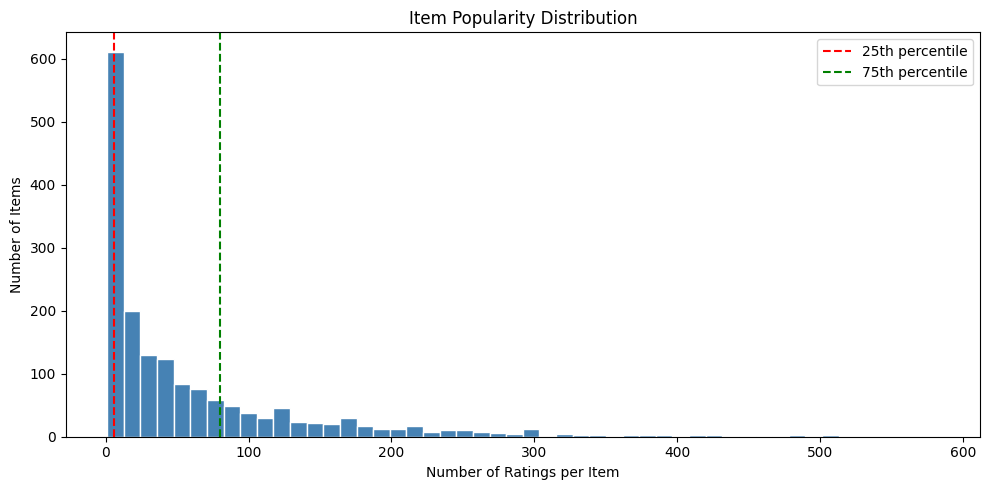

In [ ]:
# how ratings are distributed to find target item
print("\nRating Distribution:")
print(df['rating'].value_counts().sort_index())

# plot item popularity distribution to check tartget item range
item_popularity = df.groupby('item_id')['rating'].count().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
plt.hist(item_popularity.values, bins=50, color='steelblue', edgecolor='white')
plt.xlabel("Number of Ratings per Item")
plt.ylabel("Number of Items")
plt.title("Item Popularity Distribution")
plt.axvline(item_popularity.quantile(0.25), color='red', linestyle='--', label='25th percentile')
plt.axvline(item_popularity.quantile(0.75), color='green', linestyle='--', label='75th percentile')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# print the quantile values sas its not displayed in histogram
print("Item Popularity Quantiles:")
print(f"25th percentile: {item_popularity.quantile(0.25):.0f} ratings")
print(f"50th percentile: {item_popularity.quantile(0.50):.0f} ratings")
print(f"75th percentile: {item_popularity.quantile(0.75):.0f} ratings")


Item Popularity Quantiles:
25th percentile: 6 ratings
50th percentile: 27 ratings
75th percentile: 80 ratings


## Class for managing dataset


In [ ]:

class DataManager:
    def __init__(self):
        raw_data = Dataset.load_builtin('ml-100k')
        self.df = pd.DataFrame(raw_data.raw_ratings, columns=['user_id', 'item_id', 'rating', 'timestamp'])
        self.min_rating = self.df['rating'].min()
        self.max_rating = self.df['rating'].max()
        self.all_items = self.df['item_id'].unique().tolist()
        self.all_users = self.df['user_id'].unique().tolist()
        self.item_popularity = self.df.groupby('item_id')['rating'].count()
        self.item_avg_ratings = self.df.groupby('item_id')['rating'].mean().to_dict()

        # precompute popular items for bandwagon attack
        # widely like = high avg rating value + high rating count(popular)
        popularity_norm = self.item_popularity / self.item_popularity.max()
        avg_rating_series = pd.Series(self.item_avg_ratings)
        avg_norm = avg_rating_series / avg_rating_series.max()
        popularity_score = (popularity_norm + avg_norm) / 2
        self.popular_items = popularity_score.sort_values(ascending=False).index.tolist()

    def get_trainset(self, extra_ratings=None):
        # extra ratings = fake profiles to be added to trainset
        # will be empty for the first base case - without fake profile to compare the effect of attacks
        if extra_ratings is not None:
            extra_df = pd.DataFrame(extra_ratings, columns=['user_id', 'item_id', 'rating', 'timestamp'])
            combined_df = pd.concat([self.df, extra_df], ignore_index=True)
        else:
            combined_df = self.df
        reader = Reader(rating_scale=(self.min_rating, self.max_rating))
        surprise_data = Dataset.load_from_df(combined_df[['user_id', 'item_id', 'rating']], reader)
        return surprise_data.build_full_trainset()

    def get_num_users(self):
        return len(self.all_users)

dm = DataManager()

### Find best items for nuke and push attacks.


In [ ]:
# load movie names
movies_file = os.path.expanduser('~/.surprise_data/ml-100k/ml-100k/u.item')
movies_df = pd.read_csv(movies_file, sep='|', header=None, encoding='latin-1', usecols=[0, 1])
movies_df.columns = ['item_id', 'title']
movies_df['item_id'] = movies_df['item_id'].astype(str)

# push candidates - moderately popular items (40-60 ratings)
# not being recommended to anyone yet so push attack has room to be pushed to people as recommendations
mask_push = (dm.item_popularity >= 40) & (dm.item_popularity <= 60)
push_ids = [str(i) for i in dm.item_popularity[mask_push].index.tolist()]
push_candidates = movies_df[movies_df['item_id'].isin(push_ids)].copy()
push_candidates['num_ratings'] = push_candidates['item_id'].map(dm.item_popularity)
push_candidates['avg_rating'] = push_candidates['item_id'].map(dm.item_avg_ratings).round(2)
print("Push candidates (40-60 ratings):")
print(push_candidates.sort_values('avg_rating').to_string(index=False))

# nuke candidates - very popular items (300+ ratings)
# already being recommended to many users so nuke attack has room to be suppressed
mask_nuke = (dm.item_popularity >= 300)
nuke_ids = [str(i) for i in dm.item_popularity[mask_nuke].index.tolist()]
nuke_candidates = movies_df[movies_df['item_id'].isin(nuke_ids)].copy()
nuke_candidates['num_ratings'] = nuke_candidates['item_id'].map(dm.item_popularity)
nuke_candidates['avg_rating'] = nuke_candidates['item_id'].map(dm.item_avg_ratings).round(2)
print("\nNuke candidates (300-400 ratings):")
print(nuke_candidates.sort_values('num_ratings', ascending=False).to_string(index=False))

Push candidates (40-60 ratings):
item_id                                                             title  num_ratings  avg_rating
    688                                         Leave It to Beaver (1997)           44        1.84
    890                                Mortal Kombat: Annihilation (1997)           43        1.95
    931                                  Island of Dr. Moreau, The (1996)           57        2.16
    948                                                 Booty Call (1997)           48        2.17
    577                                                  Coneheads (1993)           41        2.22
   1079                                            Joe's Apartment (1996)           45        2.24
    456                                        Beverly Hills Ninja (1997)           48        2.31
    683                                                 Rocket Man (1997)           49        2.41
    769                                                      Congo (1995)   

In [ ]:
# push targets - different avg ratings to see how attack works on different quality
# 806: Menace II Society (1993) - avg 3.46, neutral rating
# 688: Leave It to Beaver (1997) - avg 1.84, poorly rated
PUSH_TARGET_ITEMS = ['806', '688']

# nuke targets - popular items already being recommended to some users
# PS: considered different items for nuke: but many wern't being recommended and
# it was hard to find something that is already being recommended and that could be supressed
NUKE_TARGET_ITEMS = ['313', '172']

# 313: Titanic (1997) - avg 4.25
# 172: Empire Strikes Back (1980) - avg - 4.2

In [ ]:

class ShillingAttack(ABC):
    def __init__(self, data_manager, attack_size_pct, push=True):
        self.dm = data_manager

        # push = True mean push attack
        # push = False means nuke attack
        self.push = push

        # calculate number of fake users based on percentage of real users
        self.num_fake_users = int(data_manager.get_num_users() * attack_size_pct)

    def _get_target_rating(self):
        # push attack gives target item max rating, nuke attack gives it min rating
        return self.dm.max_rating if self.push else self.dm.min_rating

    def _get_fake_user_id(self, index):
        # unique fake user id that can be distinguished from real user id's for experiments
        return f"fake_user_{index}"

    @abstractmethod
    def generate_profiles(self, target_item):
        # subclasses return a list of fake user profile tuples specidic to each attack
        pass

In [ ]:
class BandwagonAttack(ShillingAttack):
    def __init__(self, data_manager, attack_size_pct, push=True, filler_size=0.1, num_bandwagon=20):
        super().__init__(data_manager, attack_size_pct, push)

        # rate additinoal items randomly in addition to the popular items
        self.filler_size = filler_size

        # num_bandwagon - num of widely like items to be rated for each fake profile
        self.num_bandwagon = num_bandwagon

    def generate_profiles(self, target_item):
        profiles = []

        # get top popular items excluding the target
        bandwagon_items = [str(item) for item in self.dm.popular_items
                          if str(item) != str(target_item)][:self.num_bandwagon]

        # remaining items for random filler - exclude target and bandwagon items
        filler_items = [str(item) for item in self.dm.all_items
                       if str(item) != str(target_item) and str(item) not in bandwagon_items]

        num_filler = int(len(filler_items) * self.filler_size)

        for i in range(self.num_fake_users):
            user_id = self._get_fake_user_id(i)

            # rate target item
            profiles.append((user_id, str(target_item), self._get_target_rating(), 0))

            # rate all bandwagon items with max rating
            for item in bandwagon_items:
                profiles.append((user_id, str(item), self.dm.max_rating, 0))

            # add random filler ratings in the scale ratings
            selected_fillers = np.random.choice(filler_items, size=num_filler, replace=False)
            for item in selected_fillers:
                rating = float(np.random.randint(int(self.dm.min_rating), int(self.dm.max_rating) + 1))
                profiles.append((user_id, str(item), rating, 0))

        return profiles

In [ ]:
class AverageAttack(ShillingAttack):
    def __init__(self, data_manager, attack_size_pct, push=True, filler_size=0.1):
        super().__init__(data_manager, attack_size_pct, push)

        # filler_size is the percent of items each fake user will rate
        self.filler_size = filler_size

    def generate_profiles(self, target_item):
        profiles = []

        # get candidates items for filler ratings excluding target
        filler_items = [str(item) for item in self.dm.all_items if str(item) != str(target_item)]

        num_filler = int(len(filler_items) * self.filler_size)

        for i in range(self.num_fake_users):
            user_id = self._get_fake_user_id(i)

            # rating target item
            profiles.append((user_id, str(target_item), self._get_target_rating(), 0))

            # rate items picked randomly with real average rating
            selected_fillers = np.random.choice(filler_items, size=num_filler, replace=False)
            for item in selected_fillers:
                # round to nearest 0.5 to stay on valid rating scale
                avg = self.dm.item_avg_ratings[str(item)]
                rating = round(avg * 2) / 2
                profiles.append((user_id, str(item), rating, 0))

        return profiles

In [ ]:
# test both attack to generate dake profile
bandwagon_attack = BandwagonAttack(dm, attack_size_pct=0.05, push=True)
avg_attack = AverageAttack(dm, attack_size_pct=0.05, push=True)

bandwagon_profiles = bandwagon_attack.generate_profiles(PUSH_TARGET_ITEMS[0])
avg_profiles = avg_attack.generate_profiles(PUSH_TARGET_ITEMS[0])

print("Bandwagon Attack profiles generated:", len(bandwagon_profiles))
print("Average Attack profiles generated:", len(avg_profiles))
print("\nSample Bandwagon Push Attack profile:")
print(bandwagon_profiles[:3])
print("\nSample Average Push Attack profile:")
print(avg_profiles[:3])

# also test nuke
bandwagon_attack_nuke = BandwagonAttack(dm, attack_size_pct=0.05, push=False)
avg_attack_nuke = AverageAttack(dm, attack_size_pct=0.05, push=False)

bandwagon_profiles_nuke = bandwagon_attack_nuke.generate_profiles(NUKE_TARGET_ITEMS[0])
avg_profiles_nuke = avg_attack_nuke.generate_profiles(NUKE_TARGET_ITEMS[0])

print("\nSample Bandwagon Nuke Attack profile:")
print(bandwagon_profiles_nuke[:3])
print("\nSample Average Nuke Attack profile:")
print(avg_profiles_nuke[:3])

Bandwagon Attack profiles generated: 8789
Average Attack profiles generated: 7943

Sample Bandwagon Push Attack profile:
[('fake_user_0', '806', 5.0, 0), ('fake_user_0', '50', 5.0, 0), ('fake_user_0', '100', 5.0, 0)]

Sample Average Push Attack profile:
[('fake_user_0', '806', 5.0, 0), ('fake_user_0', '1433', 2.0, 0), ('fake_user_0', '1324', 2.5, 0)]

Sample Bandwagon Nuke Attack profile:
[('fake_user_0', '313', 1.0, 0), ('fake_user_0', '50', 5.0, 0), ('fake_user_0', '100', 5.0, 0)]

Sample Average Nuke Attack profile:
[('fake_user_0', '313', 1.0, 0), ('fake_user_0', '206', 3.5, 0), ('fake_user_0', '531', 4.0, 0)]


In [ ]:
from surprise import KNNBasic, SVD

class RecommenderAlgorithm(ABC):
    def __init__(self):
        self.model = None
        self.trainset = None

    @abstractmethod
    def build_model(self):
        # subclasses define algorithm
        pass

    def train(self, trainset):
        self.trainset = trainset
        self.model = self.build_model()
        self.model.fit(trainset)

    def get_top_n(self, n=10):
        # get top N recommendations for all real users
        # returns dict of items for each user - {user_id: [item_id, ...]}
        recommendations = {}

        for user_id in self.trainset.all_users():
            # get the raw user id
            raw_user_id = self.trainset.to_raw_uid(user_id)

            # skip fake users for recommendations
            if str(raw_user_id).startswith('fake_user'):
                continue

            # get all items this user hasn't rated yet
            rated_items = set([self.trainset.to_raw_iid(i) for i, _ in self.trainset.ur[user_id]])
            unrated_items = [item for item in self.trainset.all_items()
                           if self.trainset.to_raw_iid(item) not in rated_items]

            # predict ratings for all unrated items
            predictions = [(self.trainset.to_raw_iid(item),
                          self.model.predict(raw_user_id, self.trainset.to_raw_iid(item)).est)
                         for item in unrated_items]

            # sort by predicted rating and take top N
            predictions.sort(key=lambda x: x[1], reverse=True)
            recommendations[raw_user_id] = [item_id for item_id, _ in predictions[:n]]

        return recommendations

In [ ]:

class KNNRecommender(RecommenderAlgorithm):
    def build_model(self):
        # user-based KNN
        return KNNBasic(sim_options={'user_based': True})


class SVDRecommender(RecommenderAlgorithm):
    def build_model(self):
        # SVD - matrix factorization
        return SVD()

In [ ]:
class Simulator:
    def __init__(self, data_manager, push_target_items, nuke_target_items, n_trials=3, top_n=20):
        self.dm = data_manager
        self.push_target_items = push_target_items
        self.nuke_target_items = nuke_target_items
        self.n_trials = n_trials
        self.top_n = top_n

    def _measure_attack_power(self, recommender, attack, target_item):
        # generate fake profiles
        fake_profiles = attack.generate_profiles(target_item)

        # train recommender with fake profiles
        poisoned_trainset = self.dm.get_trainset(extra_ratings=fake_profiles if fake_profiles else None)
        recommender.train(poisoned_trainset)

        recommendations = recommender.get_top_n(n=self.top_n)

        # calculate percent of real users who got the target item in their recommendations
        target_count = sum(1 for recs in recommendations.values() if target_item in recs)
        return target_count / len(recommendations), recommendations

In [50]:
# 0 means no fake users for baseline
attack_sizes = [0.0, 0.01, 0.03, 0.05, 0.10]
recommender_classes = {'KNN': KNNRecommender, 'SVD': SVDRecommender}
attack_classes = {'Bandwagon': BandwagonAttack, 'Average': AverageAttack}
attack_modes = {'Push': True, 'Nuke': False}

results = []

simulator = Simulator(dm, push_target_items=PUSH_TARGET_ITEMS, nuke_target_items=NUKE_TARGET_ITEMS, n_trials=3, top_n=20)

for attack_name, attack_class in attack_classes.items():
    for mode_name, push in attack_modes.items():
        target_items = PUSH_TARGET_ITEMS if push else NUKE_TARGET_ITEMS
        for rec_name, rec_class in recommender_classes.items():
            for size in attack_sizes:
                for target_item in target_items:
                    print(f"\n{attack_name} {mode_name} Attack | {rec_name} | Size: {size*100:.0f}% | Item: {target_item}")

                    # run multiple trials each target item
                    trial_powers = []
                    for trial in range(simulator.n_trials):
                        recommender = rec_class()
                        attack = attack_class(dm, size, push=push)
                        power, recommendations = simulator._measure_attack_power(recommender, attack, target_item)
                        trial_powers.append(power)
                        print(f"  Trial {trial+1}/{simulator.n_trials} -- attack power: {power:.2%}")

                    # average the power for each item
                    avg_power = np.mean(trial_powers)
                    print(f"  Average: {avg_power:.2%}")

                    # save recommendations each target item
                    save_name = f"{rec_name}_{attack_name}_item{target_item}_size{int(size*100)}"
                    recs_path = os.path.join(SAVE_DIR, f"{save_name}_recs.pkl")
                    with open(recs_path, 'wb') as f:
                        pickle.dump(recommendations, f)

                    # store result per item
                    results.append({
                        'attack_type': attack_name,
                        'attack_mode': mode_name,
                        'recommender': rec_name,
                        'target_item': target_item,
                        'attack_size_pct': size * 100,
                        'attack_power': avg_power * 100
                    })

                    # save results after every combination
                    results_df = pd.DataFrame(results)
                    results_df.to_csv(os.path.join(SAVE_DIR, 'results.csv'), index=False)
                    with open(os.path.join(SAVE_DIR, 'results.pkl'), 'wb') as f:
                        pickle.dump(results_df, f)

# final results
results_df = pd.DataFrame(results)
results_df.to_csv(os.path.join(SAVE_DIR, 'results_final.csv'), index=False)
with open(os.path.join(SAVE_DIR, 'results_final.pkl'), 'wb') as f:
    pickle.dump(results_df, f)

print("Results saved to drive")
print("\nFull Results:")
print(results_df.to_string(index=False))


Bandwagon Push Attack | KNN | Size: 0% | Item: 806
Computing the msd similarity matrix...
Done computing similarity matrix.
  Trial 1/3 -- attack power: 0.00%
Computing the msd similarity matrix...
Done computing similarity matrix.
  Trial 2/3 -- attack power: 0.00%
Computing the msd similarity matrix...
Done computing similarity matrix.
  Trial 3/3 -- attack power: 0.00%
  Average: 0.00%

Bandwagon Push Attack | KNN | Size: 0% | Item: 688
Computing the msd similarity matrix...
Done computing similarity matrix.
  Trial 1/3 -- attack power: 0.00%
Computing the msd similarity matrix...
Done computing similarity matrix.
  Trial 2/3 -- attack power: 0.00%
Computing the msd similarity matrix...
Done computing similarity matrix.
  Trial 3/3 -- attack power: 0.00%
  Average: 0.00%

Bandwagon Push Attack | KNN | Size: 1% | Item: 806
Computing the msd similarity matrix...
Done computing similarity matrix.
  Trial 1/3 -- attack power: 0.00%
Computing the msd similarity matrix...
Done computing 

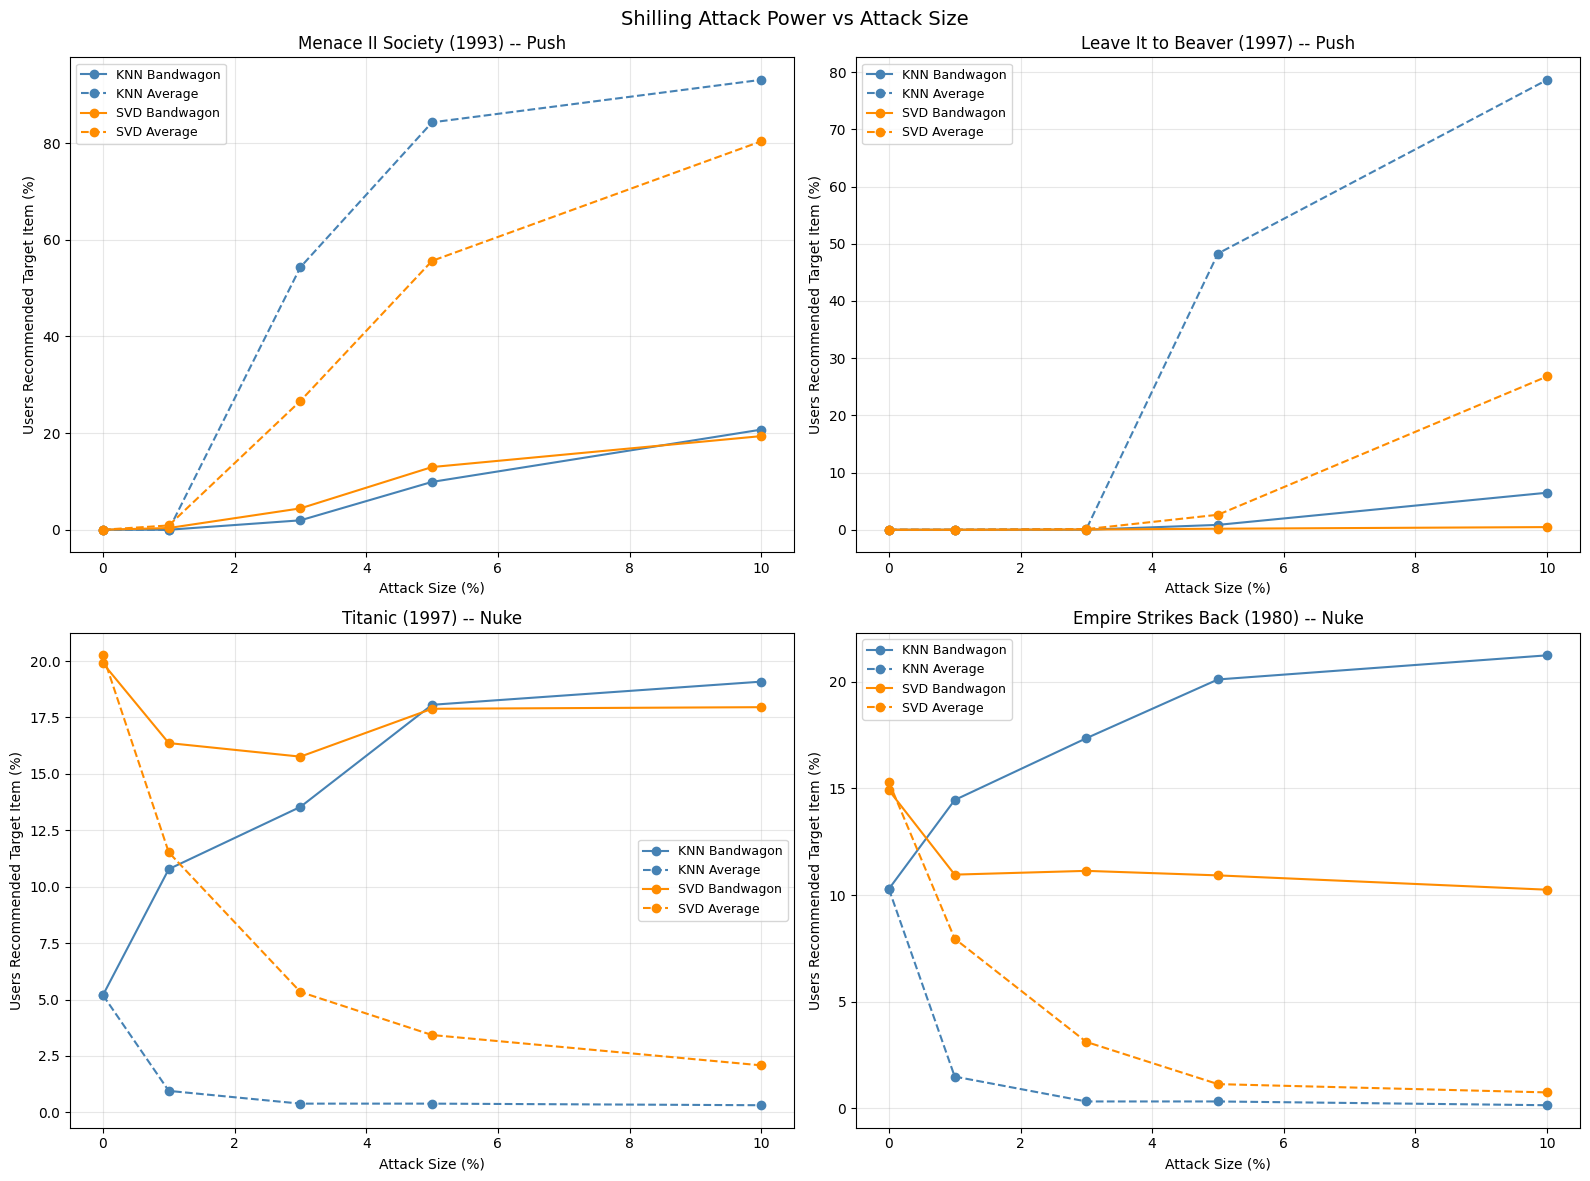

Plot saved to drive


In [53]:
# AI Attribution
# initially had separate plots for each algorithm and attack type combination
# used Gemini to debug and restructure into a 4 plot figure with multiple lines per plot
# which made it much easier to compare attack types and algorithms side by side

item_names = {
    '806': 'Menace II Society (1993) -- Push',
    '688': 'Leave It to Beaver (1997) -- Push',
    '313': 'Titanic (1997) -- Nuke',
    '172': 'Empire Strikes Back (1980) -- Nuke',
}

item_modes = {
    '806': 'Push',
    '688': 'Push',
    '313': 'Nuke',
    '172': 'Nuke',
}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Shilling Attack Power vs Attack Size', fontsize=14)

all_items = ['806', '688', '313', '172']

line_styles = {
    ('KNN', 'Bandwagon'): ('steelblue', '-'),
    ('KNN', 'Average'):   ('steelblue', '--'),
    ('SVD', 'Bandwagon'): ('darkorange', '-'),
    ('SVD', 'Average'):   ('darkorange', '--'),
}

for ax, item_id in zip(axes.flatten(), all_items):
    mode = item_modes[item_id]
    subset = results_df[
        (results_df['target_item'] == item_id) &
        (results_df['attack_mode'] == mode)
    ]

    for (rec, attack), (color, linestyle) in line_styles.items():
        data = subset[
            (subset['recommender'] == rec) &
            (subset['attack_type'] == attack)
        ].sort_values('attack_size_pct')

        ax.plot(data['attack_size_pct'], data['attack_power'],
               marker='o',
               color=color,
               linestyle=linestyle,
               label=f"{rec} {attack}")

    ax.set_title(item_names[item_id])
    ax.set_xlabel('Attack Size (%)')
    ax.set_ylabel('Users Recommended Target Item (%)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'shilling_results.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved to drive")

## Findings


### Push Attack Results

- Average Attack consistently outperforms Bandwagon Attack for push on both KNN and SVD
- KNN is more prone when compared to SVD for both Push attacks
- Leave It to Beaver (avg 1.84) is harder to push than Menace II Society (avg 3.46), which may symbolise that item quality affects attack effectiveness
- Both items follow the same trend, attack power increases monotonically with attack size


### Nuke Attack Results

- Average Attack is highly effective for nuke on both algorithms in supressing recommendations
- KNN Average is the most effective nuke attack. It suppresses recommendations almost completely at small attack sizes. This also means that SVD is less prone to such attacks.
- Bandwagon Attack backfires for KNN nuke, because recommendation rate actually increases instead of decreasing. This is because fake users rating popular items highly inadvertently make the target popular items look more appealing to KNN neighbors even though it is rated low in the fake profiles


### Advice

- Even a small number of fake profiles can change recommendations. And we should monitor for sudden changes in recommendation patterns for items.
- KNN is more vulnerable than SVD. But even SVD is not immune and hence we need proactive measures to filter our attackers.
- Implement anamoly detection rules to filter user who rate items exectly the average of the items.
- Filter out profiles that all rate the same items with same ratings or have a high correlation. Like in bandwagon, all profiles rate the popular items.
